# 01 — Data

In this notebook we explain the details of AbacusSummit data, load redshift snapshots and plot them, and we write the z = 0.5 measurement artifact used by the rest of this repo.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table

ROOT      = Path('/n/home03/hbrittain/COSMO')
DATA      = ROOT / 'data'
ARTIFACTS = ROOT / 'artifacts' / 'measurements'
ARTIFACTS.mkdir(parents=True, exist_ok=True)

### AbacusSummit

AbacusSummit is a large suite of cosmological N-body simulations run on OLCF Summit, designed to meet Stage-IV survey requirements. We use `AbacusSummit_base_c000_ph000` — Planck 2018 LambdaCDM, a 2 Gpc/h box with 6912^3 particles — at 12 full redshift snapshots from z = 0.1 to 3.0. The data was downloaded from the public AbacusSummit Globus collection via the Globus File Manager at app.globus.org.

In [2]:
# each snapshot: a header + a power spectrum CSV
for snap in sorted(DATA.glob('z*/AB')):
    files = sorted(f.name for f in snap.iterdir())
    print(f"{snap.parent.name}/AB/  ->  {files}")

z0.100/AB/  ->  ['header', 'power_nfft2048.csv', 'power_nfft2048.png', 'power_nfft2048_zspace.csv', 'power_nfft2048_zspace.png']
z0.200/AB/  ->  ['header', 'power_nfft2048.csv', 'power_nfft2048.png', 'power_nfft2048_zspace.csv', 'power_nfft2048_zspace.png']
z0.300/AB/  ->  ['header', 'power_nfft2048.csv', 'power_nfft2048.png', 'power_nfft2048_zspace.csv', 'power_nfft2048_zspace.png']
z0.400/AB/  ->  ['header', 'power_nfft2048.csv', 'power_nfft2048.png', 'power_nfft2048_zspace.csv', 'power_nfft2048_zspace.png']
z0.500/AB/  ->  ['.ipynb_checkpoints', 'header', 'power_nfft2048.csv', 'power_nfft2048.png', 'power_nfft2048_zspace.csv', 'power_nfft2048_zspace.png']
z0.800/AB/  ->  ['header', 'power_nfft2048.csv', 'power_nfft2048.png', 'power_nfft2048_zspace.csv', 'power_nfft2048_zspace.png']
z1.100/AB/  ->  ['header', 'power_nfft2048.csv', 'power_nfft2048.png', 'power_nfft2048_zspace.csv', 'power_nfft2048_zspace.png']
z1.400/AB/  ->  ['header', 'power_nfft2048.csv', 'power_nfft2048.png', 'pow

### The Header

Each snapshot ships with a plain-text `header` in `key = value` format. The first block is the input parameter file (cosmology, box size, output schedule); the second block is runtime diagnostics computed at this snapshot. The fields we use downstream:

- <span style="color:pink">*Growth*</span>: linear growth factor $D(z)$, used to scale the CLASS spectrum to the snapshot redshift
- <span style="color:pink">*f_growth*</span>: logarithmic growth rate $f = d\ln D / d\ln a$
- <span style="color:pink">*ZD_Pk_file_redshift*</span>: redshift where the input CLASS spectrum is defined (z = 1); all linear baselines scale from here

In [3]:
header_path = DATA / 'z0.500' / 'AB' / 'header'

raw = {}
for line in header_path.read_text().splitlines():
    line = line.strip()
    if not line or line.startswith('#') or '=' not in line:
        continue
    key, _, val = line.partition('=')
    key, val = key.strip(), val.strip().strip('"')
    try:
        raw[key] = float(val)
    except ValueError:
        raw[key] = val

keys = ['SimName', 'Redshift', 'BoxSizeHMpc', 'H0',
        'Omega_M', 'n_s', 'omega_b', 'omega_cdm', 'omega_ncdm',
        'Growth', 'f_growth', 'ZD_Pk_file_redshift']
for k in keys:
    if k in raw:
        print(f"{k:<28} {raw[k]}")

SimName                      AbacusSummit_base_c000_ph000
Redshift                     0.5
BoxSizeHMpc                  2000.0
H0                           67.36
Omega_M                      0.315192
n_s                          0.9649
omega_b                      0.02237
omega_cdm                    0.12
omega_ncdm                   0.0006442
Growth                       0.606627373179928
f_growth                     0.759069923632896
ZD_Pk_file_redshift          1.0


### The Power Spectrum File

`power_nfft2048.csv` is in ECSV format (Astropy's Enhanced CSV, with column metadata embedded in comment lines). The `nfft2048` tag gives the FFT mesh: 2048^3 on a 2 Gpc/h box, so $k_{\rm Nyq} = \pi \times 2048 / 2000 \approx 3.2\, h/{\rm Mpc}$. The `AB` folder means this was computed from the combined A + B particle sub-samples (10% of the full catalog).

Columns:
- <span style="color:pink">*kavg*</span> ($h/{\rm Mpc}$): shell-averaged wavenumber
- <span style="color:pink">*power*</span> $({\rm Mpc}/h)^3$: measured $P(k)$
- <span style="color:pink">*N_modes*</span>: independent Fourier modes in the shell — sets the measurement precision

In [4]:
csv_path = DATA / 'z0.500' / 'AB' / 'power_nfft2048.csv'
tab      = Table.read(csv_path, format='ascii.ecsv')
df_peek  = tab.to_pandas()
df_peek  = df_peek[df_peek['kavg'] > 0].copy()

print(f"columns: {list(df_peek.columns)}")
print(f"k range: {df_peek['kavg'].min():.4f} - {df_peek['kavg'].max():.3f} h/Mpc  ({len(df_peek)} bins)")
df_peek.head(6)

columns: ['kmin', 'kmax', 'kavg', 'power', 'N_modes']
k range: 0.0040 - 3.216 h/Mpc  (2046 bins)


,kmin,kmax,kavg,power,N_modes
2,0.003142,0.004712,0.004009,4781.058105,18
3,0.004712,0.006283,0.005441,10533.492188,8
4,0.006283,0.007854,0.007240,12056.625977,54
5,0.007854,0.009425,0.008886,10081.497070,12
6,0.009425,0.010996,0.009980,10820.314453,86
7,0.010996,0.012566,0.011612,14838.739258,72


### N_modes and Measurement Precision

For a Gaussian field, the power estimator has variance $\sigma^2(k) = 2P(k)^2 / N_{\rm modes}(k)$. The mode count grows as $\sim k^2$, so precision improves quickly toward smaller scales.

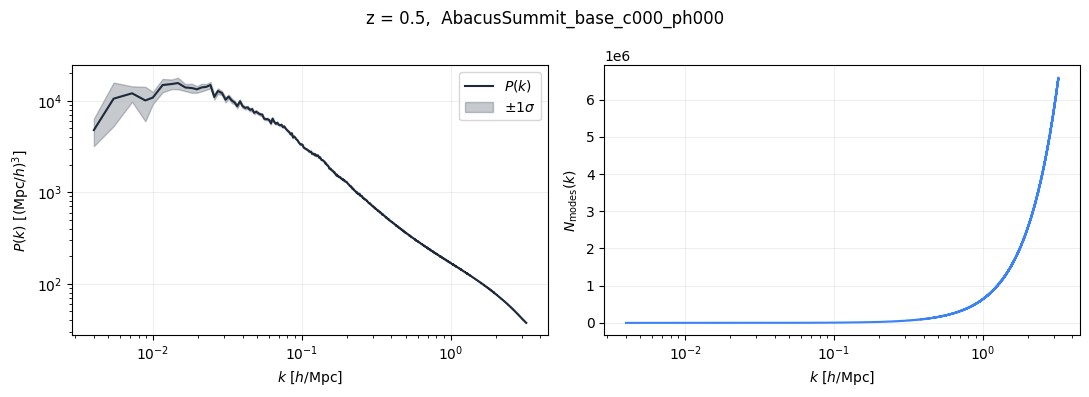

In [5]:
k      = df_peek['kavg'].to_numpy()
p      = df_peek['power'].to_numpy()
nmodes = df_peek['N_modes'].to_numpy()
sigma  = np.sqrt(2) * p / np.sqrt(nmodes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.loglog(k, p, color='#1e293b', linewidth=1.5, label=r'$P(k)$')
ax1.fill_between(k, p - sigma, p + sigma, alpha=0.25, color='#1e293b', label=r'$\pm 1\sigma$')
ax1.set_xlabel(r'$k\ [h/{\rm Mpc}]$')
ax1.set_ylabel(r'$P(k)\ [({\rm Mpc}/h)^3]$')
ax1.legend()
ax1.grid(alpha=0.2)

ax2.semilogx(k, nmodes, color='#3b82f6')
ax2.set_xlabel(r'$k\ [h/{\rm Mpc}]$')
ax2.set_ylabel(r'$N_{\rm modes}(k)$')
ax2.grid(alpha=0.2)

fig.suptitle('z = 0.5,  AbacusSummit_base_c000_ph000')
fig.tight_layout()
plt.show()

### Redshift Suite

In [6]:
spectra = {}
headers = {}

for path in sorted(DATA.glob('z*/AB/power_nfft2048.csv')):
    z = float(path.parent.parent.name[1:])
    tab = Table.read(path, format='ascii.ecsv')
    df = tab.to_pandas()
    spectra[z] = df[df['kavg'] > 0].copy()

for path in sorted(DATA.glob('z*/AB/header')):
    z = float(path.parent.parent.name[1:])
    header = {}
    for line in path.read_text().splitlines():
        if '=' not in line:
            continue
        key, _, value = line.partition('=')
        header[key.strip()] = value.strip().strip('"')
    headers[z] = header

sorted(spectra), len(spectra)

([0.1, 0.2, 0.3, 0.4, 0.5, 0.8, 1.1, 1.4, 1.7, 2.0, 2.5, 3.0], 12)

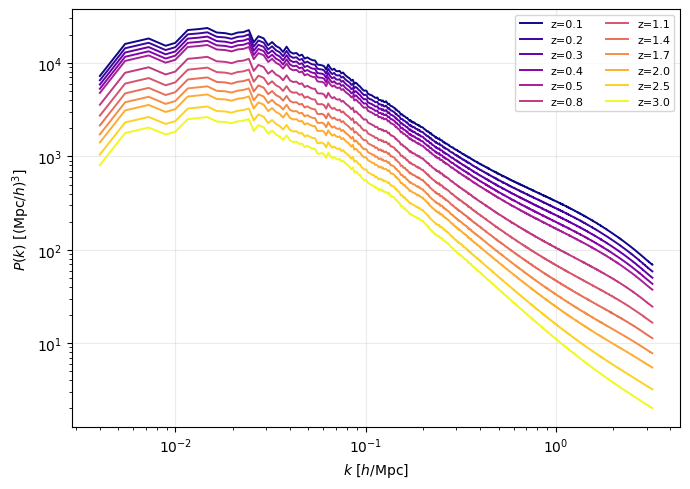

In [7]:
cmap  = plt.cm.plasma
zvals = sorted(spectra)
fig, ax = plt.subplots(figsize=(7, 5))
for i, z in enumerate(zvals):
    color = cmap(i / max(len(zvals) - 1, 1))
    d = spectra[z]
    ax.loglog(d['kavg'], d['power'], color=color, linewidth=1.4, label=f'z={z:.1f}')

ax.set_xlabel(r'$k\ [h/{\rm Mpc}]$')
ax.set_ylabel(r'$P(k)\ [({\rm Mpc}/h)^3]$')
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Saving Measurement

The fitting code expects standardised column names (`k_h_per_Mpc`, `P0`, `nmodes`). We save z = 0.5 and write a sidecar metadata JSON.

In [8]:
z_choice = 0.5
df = spectra[z_choice].copy()
header = headers[z_choice]

measurement = pd.DataFrame({
    'k_h_per_Mpc': df['kavg'].to_numpy(),
    'P0':          df['power'].to_numpy(),
    'nmodes':      df['N_modes'].to_numpy(),
})

csv_path  = ARTIFACTS / f'matter_pk_real_z{z_choice:.3f}.csv'
meta_path = ARTIFACTS / f'matter_pk_real_z{z_choice:.3f}.metadata.json'
measurement.to_csv(csv_path, index=False)
meta = {
    'observable_type': 'matter_pk_real',
    'redshift': z_choice,
    'box_size_hMpc': float(header['BoxSize']),
    'sim_name': header.get('SimName', 'unknown'),
    'shot_noise_subtracted': False,
    'source_power_csv': str(DATA / f'z{z_choice:.3f}' / 'AB' / 'power_nfft2048.csv'),
}
meta_path.write_text(json.dumps(meta, indent=2))

csv_path, meta_path

(PosixPath('/n/home03/hbrittain/COSMO/artifacts/measurements/matter_pk_real_z0.500.csv'),
 PosixPath('/n/home03/hbrittain/COSMO/artifacts/measurements/matter_pk_real_z0.500.metadata.json'))